[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter6_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 6: VAR models and Granger causality

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- From one series to several: Romanian macro data, cross-correlations of markets.
- The VAR(p) model: a worked VAR(1), stability, the companion matrix.
- Estimation by OLS, lag selection (AIC, BIC, HQ), residual diagnostics.
- Granger causality: Romania, S&P 500 / DAX / BET, the omitted-variable pitfall.
- Impulse responses (Cholesky, ordering, generalised), FEVD, the Diebold–Yilmaz spillover index.
- Forecasting and out-of-sample evaluation; the Stock–Watson (2001) VAR.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 7; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Sec. 12.3; Lütkepohl (2005); Hamilton (1994), Ch. 11; Stock and Watson (2001).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- VAR(p): $\mathbf{Y}_t = \mathbf{c} + \mathbf{A}_1\mathbf{Y}_{t-1} + \dots + \mathbf{A}_p\mathbf{Y}_{t-p} + \boldsymbol{\varepsilon}_t$, estimated with `VAR` from `statsmodels` (`fit_var(d, p)`).
- `ro_var_data()`: Romanian quarterly GDP growth `g`, 12-month inflation `pi`, ROBOR 3M `i` (2005Q1–2026Q2).
- `ic_table(d, pmax)`: AIC, BIC, HQ on a common sample; `granger_F(d, cause, effect, p)`: the Granger $F$ test.
- `girf(res, H)`: generalised impulse responses; `gfevd(res, H)`: generalised FEVD (Diebold–Yilmaz); `boot_irf(res, H)`: residual-bootstrap bands.

In [5]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
SEED = 2026
GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
ROBOR = ('irt_st_m', 'M.IRT_M3.RO')
UNEMP = ('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO')
RO_START = '2005-01-01'
RO_VARS = ['g', 'pi', 'i']
RO_P = 2
MKT = ['sp500', 'dax', 'bet']
MKT_START = '2000-01-01'
MKT_P = 4
DY_H, DY_W = 10, 200
SW_VARS = ['pi', 'u', 'R']
SW_START, SW_END, SW_P = '1960-01-01', '2000-10-01', 4
LABEL = {'g': 'GDP growth', 'pi': 'inflation', 'i': 'ROBOR 3M', 'u': 'unemployment', 'ds': 'EUR/RON change', 'R': 'fed funds rate', 'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET'}
COLV = {'g': st.Forest, 'pi': st.IDAred, 'i': st.MainBlue, 'u': st.Purple, 'ds': st.Amber, 'R': st.MainBlue, 'sp500': st.COL['sp500'], 'dax': st.COL['dax'], 'bet': st.COL['bet']}
BAND = st.Teal
WX_A = np.array([[0.5, 0.2], [0.3, 0.4]])
WX_C = np.array([1.2, 0.6])
WX_S = np.array([[1.0, 0.5], [0.5, 1.0]])
WX_Y = np.array([5.0, 2.0])
HERE = "."


def ro_monthly():
    """Romanian monthly series: 12-month HICP inflation, ROBOR 3M, unemployment rate (SA), EUR/RON (monthly mean of the
    BNR reference rate)."""
    hicp = read_eurostat(*HICP)
    fx = load_close('eurron').resample('MS').mean()
    return pd.concat([(100 * np.log(hicp).diff(12)).rename('pi'), read_eurostat(*ROBOR).rename('i'),
                      read_eurostat(*UNEMP).rename('u'), fx.rename('eurron')], axis=1)


def ro_quarterly(start=RO_START):
    """Romanian quarterly data: real GDP growth g (q/q, %, SA), 12-month HICP inflation pi, ROBOR 3M i, unemployment u
    (quarterly means of monthly data) and the EUR/RON change ds = 100 ln(S_t / S_{t-1}) of the quarterly mean rate."""
    m = ro_monthly()
    q = m.resample('QS').mean()
    g = 100 * np.log(read_eurostat(*GDP_SA)).diff()
    d = pd.concat([g.rename('g'), q['pi'], q['i'], q['u'], (100 * np.log(q['eurron']).diff()).rename('ds')], axis=1)
    d.index.name = 'date'
    return d.loc[start:].dropna(subset=['g'])


def ro_var_data(cols=RO_VARS, start=RO_START):
    return ro_quarterly(start)[cols].dropna()


def market_returns(names=MKT, start=MKT_START):
    """Daily log returns (%) of several markets on their common trading days."""
    return load_panel(names, start=start, kind='returns').dropna()


def us_sw(start=SW_START, end=None):
    """Stock and Watson (2001) data from FRED: inflation pi = 400 ln(P_t / P_{t-1}) of the chain-type GDP price index
    (GDPCTPI), the civilian unemployment rate u (UNRATE) and the federal funds rate R (FEDFUNDS), quarterly means."""
    f = read_fred(['GDPCTPI', 'UNRATE', 'FEDFUNDS'])
    pi = 400 * np.log(f['GDPCTPI'].dropna()).diff()
    d = pd.concat([pi.rename('pi'), f['UNRATE'].resample('QS').mean().rename('u'),
                   f['FEDFUNDS'].resample('QS').mean().rename('R')], axis=1).dropna()
    d.index.name = 'date'
    return d.loc[start:end]


def fit_var(d, p):
    m = VAR(d.reset_index(drop=True))
    return m.fit(p)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def qlabel(ts):
    ts = pd.Timestamp(ts)
    return f'{ts.year}Q{(ts.month - 1) // 3 + 1}'


def ccf(y, x, kmax):
    """Cross-correlations rho_yx(k) = Corr(y_t, x_{t-k}), k = -kmax..kmax (k > 0: x leads y)."""
    return {k: float(pd.Series(y).corr(pd.Series(x).shift(k))) for k in range(-kmax, kmax + 1)}


def companion(res):
    """Companion matrix of a fitted VAR(p) (Kp x Kp)."""
    K, p = res.neqs, res.k_ar
    F = np.zeros((K * p, K * p))
    F[:K, :] = np.hstack(res.coefs)
    if p > 1:
        F[K:, :-K] = np.eye(K * (p - 1))
    return F


def ic_table(d, pmax=8):
    """AIC, BIC and HQ for p = 0..pmax on a common sample (T = N - pmax):
    IC(p) = ln det Sigma_ML(p) + c_T p K^2 / T, with c_T = 2 (AIC), ln T (BIC), 2 ln ln T (HQ)."""
    Y = d.values
    K, N = Y.shape[1], len(Y)
    T = N - pmax
    out = {}
    for p in range(pmax + 1):
        X = np.column_stack([np.ones(T)] + [Y[pmax - j:N - j] for j in range(1, p + 1)])
        Z = Y[pmax:]
        B = np.linalg.lstsq(X, Z, rcond=None)[0]
        U = Z - X @ B
        ld = float(np.log(np.linalg.det(U.T @ U / T)))
        pen = p * K ** 2 / T
        out[p] = {'logdet': ld, 'aic': ld + 2 * pen, 'bic': ld + np.log(T) * pen, 'hq': ld + 2 * np.log(np.log(T)) * pen}
    best = {c: int(min(out, key=lambda p: out[p][c])) for c in ('aic', 'bic', 'hq')}
    return {'T': T, 'K': K, 'pmax': pmax, 'table': out, 'best': best}


def granger_F(d, cause, effect, p):
    """Granger causality F test in the equation of `effect` of a VAR(p) with all variables of d:
    F = [(RSS_R - RSS_U)/p] / [RSS_U/(T - Kp - 1)], RSS_R without the p lags of `cause`."""
    Y = d.values
    cols = list(d.columns)
    K, N = Y.shape[1], len(Y)
    T = N - p
    lags = [Y[p - j:N - j] for j in range(1, p + 1)]
    X = np.column_stack([np.ones(T)] + lags)
    keep = [0] + [1 + (j - 1) * K + k for j in range(1, p + 1) for k in range(K) if cols[k] != cause]
    y = Y[p:, cols.index(effect)]
    rss = lambda Xm: float(np.sum((y - Xm @ np.linalg.lstsq(Xm, y, rcond=None)[0]) ** 2))
    rss_u, rss_r = rss(X), rss(X[:, keep])
    df2 = T - K * p - 1
    F = ((rss_r - rss_u) / p) / (rss_u / df2)
    return {'F': float(F), 'p': float(stats.f.sf(F, p, df2)), 'rss_u': rss_u, 'rss_r': rss_r, 'T': T, 'df1': p,
            'df2': df2, 'crit5': float(stats.f.ppf(0.95, p, df2))}


def granger_table(d, p):
    cols = list(d.columns)
    return {f'{c}->{e}': granger_F(d, c, e, p) for c in cols for e in cols if c != e}


def girf(res, H):
    """Generalised impulse responses (Pesaran and Shin 1998): response at horizon h to a shock of one standard deviation
    in variable j, Phi_h Sigma e_j / sqrt(sigma_jj). Array (H+1, K, K): [h, response, shock]."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H)
    return np.array([ma[h] @ S / np.sqrt(np.diag(S))[None, :] for h in range(H + 1)])


def gfevd(res, H=DY_H):
    """Generalised FEVD normalised by rows (Diebold and Yilmaz 2012): theta[i, j] = share of the H-step forecast error
    variance of variable i due to shocks in variable j."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H - 1)
    num = sum((ma[h] @ S) ** 2 for h in range(H)) / np.diag(S)[None, :]
    den = sum(np.diag(ma[h] @ S @ ma[h].T) for h in range(H))
    th = num / den[:, None]
    return th / th.sum(axis=1, keepdims=True)


def spill_index(th):
    K = th.shape[0]
    return 100 * (th.sum() - np.trace(th)) / K


def ar_forecast(y, h, pmax=4):
    """h-step forecast of an AR(p) with constant, p chosen by AIC (p <= pmax), iterated."""
    best = min(range(1, pmax + 1), key=lambda p: AutoReg(y, lags=p, trend='c').fit().aic)
    r = AutoReg(y, lags=best, trend='c').fit()
    return float(r.forecast(h)[-1]), best


def dm_test(e1, e2, h=1):
    """Diebold-Mariano test of equal squared-error loss, with a Newey-West variance of h-1 lags; returns (DM, p)."""
    dl = np.asarray(e1) ** 2 - np.asarray(e2) ** 2
    n = len(dl)
    m = dl.mean()
    g = [np.sum((dl[k:] - m) * (dl[:n - k] - m)) / n for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = m / np.sqrt(v)
    return float(dm), float(2 * stats.norm.sf(abs(dm)))


def boot_irf(res, H, repl=500, signif=0.10, seed=SEED):
    """Residual bootstrap bands for orthogonalised impulse responses: resample the VAR residuals with replacement,
    rebuild the series from the first p observations, re-estimate the VAR(p), recompute the responses;
    percentile band of level 1 - signif."""
    rng = np.random.default_rng(seed)
    p, K = res.k_ar, res.neqs
    Y = np.asarray(res.endog)
    U = np.asarray(res.resid)
    U = U - U.mean(axis=0)
    c, A = res.intercept, res.coefs
    draws = []
    for _ in range(repl):
        y = np.zeros_like(Y)
        y[:p] = Y[:p]
        e = U[rng.integers(0, len(U), len(Y) - p)]
        for t in range(p, len(Y)):
            y[t] = c + sum(A[j] @ y[t - 1 - j] for j in range(p)) + e[t - p]
        draws.append(VAR(y).fit(p).irf(H).orth_irfs)
    draws = np.array(draws)
    return np.quantile(draws, signif / 2, axis=0), np.quantile(draws, 1 - signif / 2, axis=0)


def irf_panel(res, names, H, fname, title, repl=500, signif=0.10, save_it=True, scale=None):
    """Orthogonalised impulse responses (K x K panels) with residual-bootstrap bands."""
    irf = res.irf(H)
    lo, hi = boot_irf(res, H, repl, signif)
    K = len(names)
    fig, ax = plt.subplots(K, K, figsize=(10.0, 6.0), sharex=True)
    h = np.arange(H + 1)
    for i in range(K):
        for j in range(K):
            a = ax[i, j]
            a.fill_between(h, lo[:, i, j], hi[:, i, j], color=BAND, alpha=0.25,
                           label=f'{int(100 * (1 - signif))}% band' if (i, j) == (0, 0) else '_nolegend_')
            a.plot(h, irf.orth_irfs[:, i, j], color=COLV[names[j]], lw=1.6,
                   label='orthogonalised response' if (i, j) == (0, 0) else '_nolegend_')
            a.axhline(0, color=st.DarkText, lw=0.6)
            a.set_title(f'{LABEL[names[i]]} <- {LABEL[names[j]]} shock', fontsize=11)
            a.tick_params(labelsize=10)
            a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    for a in ax[-1]:
        a.set_xlabel('quarters' if H < 50 else 'days', fontsize=11)
    fig.suptitle(title, fontsize=13)
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save(fname, save_it)
    return irf.orth_irfs, lo, hi


def ro_fit(p=RO_P, cols=RO_VARS):
    return fit_var(ro_var_data(cols), p)

## 1. From one series to several

- Romanian macro series; cross-correlations of markets and of ROBOR with inflation.

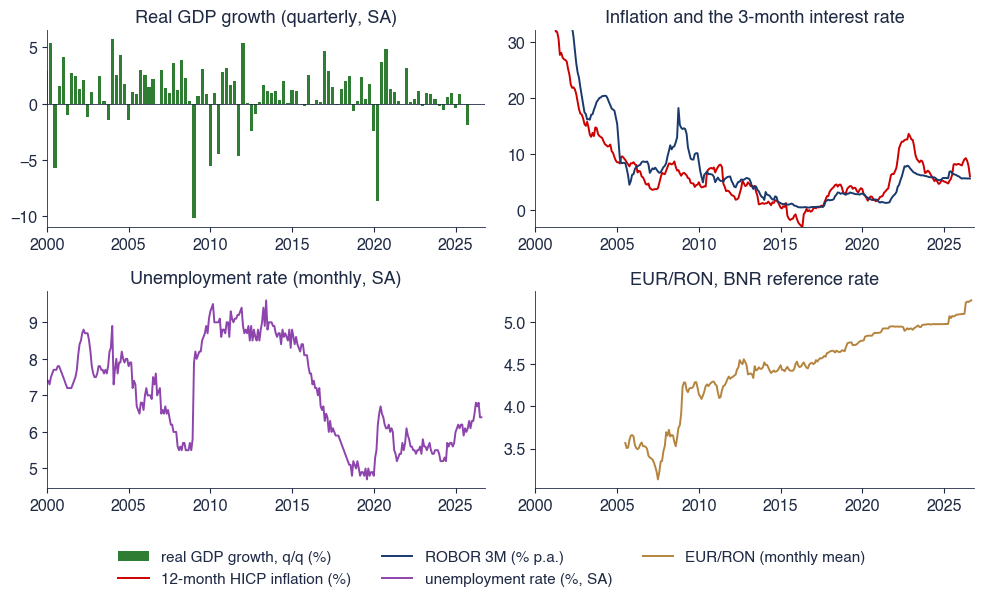

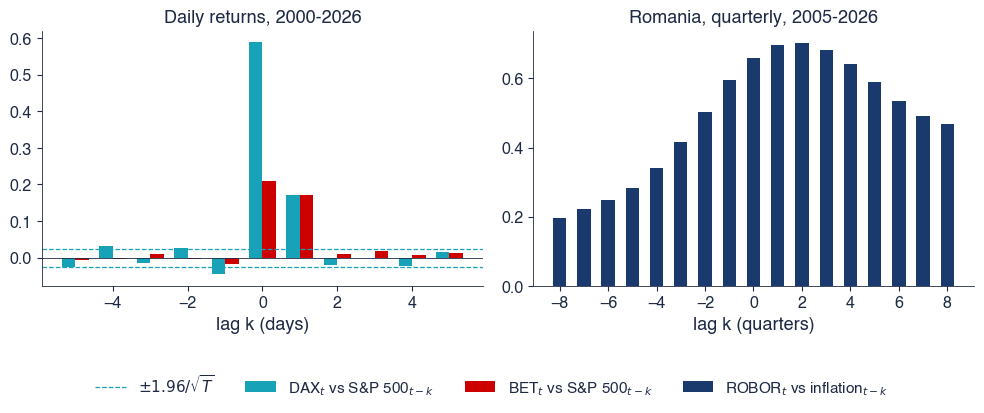

BET vs S&P 500 at lags 0 and 1: 0.21 0.172


In [6]:
def fig_ro_macro(save_it=True):
    """Romanian macro series: GDP growth (quarterly), 12-month inflation and ROBOR 3M, unemployment, EUR/RON."""
    q = ro_quarterly('2000-01-01')
    m = ro_monthly().loc['2000-01-01':]
    fig, ax = plt.subplots(2, 2, figsize=(10.0, 5.4))
    a = ax[0, 0]
    a.bar(q.index, q['g'], width=70, color=st.Forest, label='real GDP growth, q/q (%)')
    a.axhline(0, color=st.DarkText, lw=0.6)
    a.set_title('Real GDP growth (quarterly, SA)')
    a = ax[0, 1]
    a.plot(m.index, m['pi'], color=st.IDAred, label='12-month HICP inflation (%)')
    a.plot(m.index, m['i'], color=st.MainBlue, label='ROBOR 3M (% p.a.)')
    a.set_ylim(-3, 32)
    a.set_title('Inflation and the 3-month interest rate')
    a = ax[1, 0]
    a.plot(m.index, m['u'], color=st.Purple, label='unemployment rate (%, SA)')
    a.set_title('Unemployment rate (monthly, SA)')
    a = ax[1, 1]
    a.plot(m.index, m['eurron'], color=st.Amber, label='EUR/RON (monthly mean)')
    a.set_title('EUR/RON, BNR reference rate')
    for a in ax.flat:
        years_axis(a, 5)
        a.set_xlim(pd.Timestamp('2000-01-01'), m.index[-1] + pd.Timedelta(days=60))
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch6_ro_macro', save_it)
    v = ro_var_data()
    mm = m.loc[RO_START:]
    return {'q_first': str(v.index[0])[:10], 'q_last': str(v.index[-1])[:10], 'T': len(v),
            'mean': v.mean().to_dict(), 'sd': v.std().to_dict(), 'corr': v.corr().round(4).to_dict(),
            'pi_max': float(mm['pi'].max()), 'pi_max_d': str(mm['pi'].idxmax())[:10],
            'i_max': float(mm['i'].max()), 'i_max_d': str(mm['i'].idxmax())[:10],
            'pi_last': float(m['pi'].dropna().iloc[-1]), 'pi_last_d': str(m['pi'].dropna().index[-1])[:10],
            'i_last': float(m['i'].dropna().iloc[-1]), 'u_last': float(m['u'].dropna().iloc[-1]),
            'u_last_d': str(m['u'].dropna().index[-1])[:10], 'fx_last': float(m['eurron'].dropna().iloc[-1]),
            'g_min': float(q['g'].loc[RO_START:].min()), 'g_min_d': str(q['g'].loc[RO_START:].idxmin())[:10],
            'g_min2_d': str(q['g'].loc[RO_START:].nsmallest(2).index[1])[:10],
            'g_min2': float(q['g'].loc[RO_START:].nsmallest(2).iloc[1])}


def fig_ccf(save_it=True):
    """Cross-correlation functions: BET and DAX against lags of the S&P 500 (daily returns); ROBOR 3M against lags of
    inflation (quarterly)."""
    r = market_returns()
    v = ro_var_data()
    kd, kq = 5, 8
    c_bet = ccf(r['bet'], r['sp500'], kd)
    c_dax = ccf(r['dax'], r['sp500'], kd)
    c_ip = ccf(v['i'], v['pi'], kq)
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.6))
    k = np.arange(-kd, kd + 1)
    ax[0].bar(k - 0.18, [c_dax[j] for j in k], width=0.36, color=st.COL['dax'], label=r'DAX$_t$ vs S&P 500$_{t-k}$')
    ax[0].bar(k + 0.18, [c_bet[j] for j in k], width=0.36, color=st.COL['bet'], label=r'BET$_t$ vs S&P 500$_{t-k}$')
    b = 1.96 / np.sqrt(len(r))
    ax[0].axhline(b, color=BAND, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
    ax[0].axhline(-b, color=BAND, ls='--', lw=0.9, label='_nolegend_')
    ax[0].axhline(0, color=st.DarkText, lw=0.6)
    ax[0].set_xlabel('lag k (days)')
    ax[0].set_title('Daily returns, 2000-2026')
    k2 = np.arange(-kq, kq + 1)
    ax[1].bar(k2, [c_ip[j] for j in k2], width=0.55, color=st.MainBlue, label=r'ROBOR$_t$ vs inflation$_{t-k}$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_xlabel('lag k (quarters)')
    ax[1].set_title('Romania, quarterly, 2005-2026')
    for a in ax:
        a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    st.fig_legend_bottom(fig, ncol=4, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_ccf', save_it)
    kmax = max(c_ip, key=lambda j: c_ip[j])
    return {'bet': c_bet, 'dax': c_dax, 'i_pi': c_ip, 'band': float(b), 'T_daily': len(r), 'i_pi_kmax': int(kmax),
            'i_pi_max': float(c_ip[kmax]), 'first': str(r.index[0])[:10], 'last': str(r.index[-1])[:10]}


fig_ro_macro(save_it=False)
cc = fig_ccf(save_it=False)
print('BET vs S&P 500 at lags 0 and 1:', round(cc['bet'][0], 3), round(cc['bet'][1], 3))

## 2. A VAR(1) by hand and stability

- The worked example of the slides; a simulated path; eigenvalues of three estimated VARs.

{'lam': [0.7, 0.2], 'mu': [3.5, 2.7499999999999996], 'f1': [4.1, 2.9], 'f2': [3.83, 2.9899999999999998], 'A2': [[0.31, 0.18000000000000002], [0.27, 0.22000000000000003]], 'P': [[1.0, 0.0], [0.5, 0.8660254037844386]], 'Theta1': [[0.6, 0.17320508075688773], [0.5, 0.34641016151377546]], 'mse2': [[1.3900000000000001, 0.86], [0.8600000000000001, 1.37]], 'fevd2': [[0.9784172661870502, 0.021582733812949638], [0.36496350364963503, 0.6350364963503649]], 'P_rev': [[0.8660254037844386, 0.5], [0.0, 1.0]], 'Gamma0': [[1.7498860009119925, 1.2169402644778842], [1.2169402644778842, 1.7256611947104423]], 'det': 0.24000000000000005, 'tr': 0.9, 'detA': 0.14000000000000004}


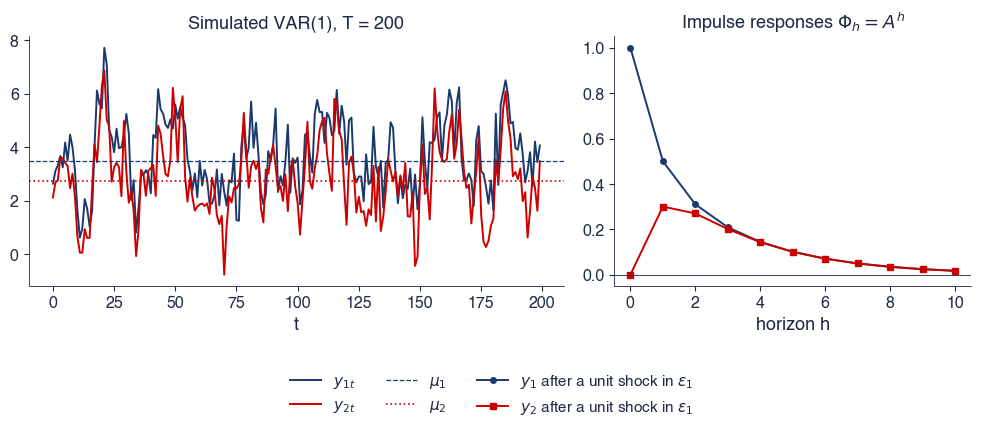

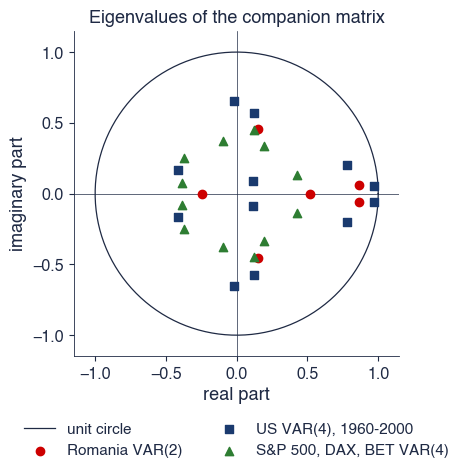

{'Romania VAR(2)': {'max_mod': 0.8694300684323825, 'n': 6, 'stable': True},
 'US VAR(4), 1960-2000': {'max_mod': 0.9690139557435103,
  'n': 12,
  'stable': True},
 'S&P 500, DAX, BET VAR(4)': {'max_mod': 0.46433300525785864,
  'n': 12,
  'stable': True}}

In [7]:
def worked_example(A=WX_A, c=WX_C, S=WX_S, yT=WX_Y):
    """All numbers of the bivariate VAR(1) worked example: eigenvalues, mean, forecasts, impulse responses
    (simple and orthogonalised), forecast error variances and their decomposition."""
    lam = np.linalg.eigvals(A)
    mu = np.linalg.solve(np.eye(2) - A, c)
    f1 = c + A @ yT
    f2 = c + A @ f1
    A2 = A @ A
    P = np.linalg.cholesky(S)
    T0, T1 = P, A @ P
    mse1, mse2 = S, S + A @ S @ A.T
    fevd2 = (T0 ** 2 + T1 ** 2) / np.diag(mse2)[:, None]
    # reversed ordering: y2 first
    Pr = np.linalg.cholesky(S[::-1, ::-1])[::-1, ::-1]
    G = np.linalg.solve(np.eye(4) - np.kron(A, A), S.reshape(-1)).reshape(2, 2)   # Gamma(0): vec G = (I - A x A)^-1 vec S
    return {'lam': sorted(lam.real.tolist(), reverse=True), 'mu': mu.tolist(), 'f1': f1.tolist(), 'f2': f2.tolist(),
            'A2': A2.tolist(), 'P': P.tolist(), 'Theta1': T1.tolist(), 'mse2': mse2.tolist(), 'fevd2': fevd2.tolist(),
            'P_rev': Pr.tolist(), 'Gamma0': G.tolist(), 'det': float(np.linalg.det(np.eye(2) - A)),
            'tr': float(np.trace(A)), 'detA': float(np.linalg.det(A))}


def fig_var_sim(T=200, H=10, save_it=True):
    """A simulated path of the worked-example VAR(1) and its impulse responses Phi_h e_1 and the orthogonalised ones."""
    rng = np.random.default_rng(SEED)
    P = np.linalg.cholesky(WX_S)
    mu = np.linalg.solve(np.eye(2) - WX_A, WX_C)
    y = np.zeros((T + 100, 2))
    y[0] = mu
    for t in range(1, T + 100):
        y[t] = WX_C + WX_A @ y[t - 1] + P @ rng.standard_normal(2)
    y = y[100:]
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.6), gridspec_kw={'width_ratios': [1.5, 1]})
    ax[0].plot(y[:, 0], color=st.MainBlue, label='$y_{1t}$')
    ax[0].plot(y[:, 1], color=st.IDAred, label='$y_{2t}$')
    ax[0].axhline(mu[0], color=st.MainBlue, ls='--', lw=0.9, label=r'$\mu_1$')
    ax[0].axhline(mu[1], color=st.IDAred, ls=':', lw=1.2, label=r'$\mu_2$')
    ax[0].set_xlabel('t')
    ax[0].set_title('Simulated VAR(1), T = 200')
    h = np.arange(H + 1)
    Ph = np.array([np.linalg.matrix_power(WX_A, j) for j in h])
    ax[1].plot(h, Ph[:, 0, 0], 'o-', color=st.MainBlue, ms=4, label=r'$y_1$ after a unit shock in $\varepsilon_1$')
    ax[1].plot(h, Ph[:, 1, 0], 's-', color=st.IDAred, ms=4, label=r'$y_2$ after a unit shock in $\varepsilon_1$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_xlabel('horizon h')
    ax[1].set_title(r'Impulse responses $\Phi_h = A^h$')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_var_sim', save_it)
    yy = pd.DataFrame(y, columns=['y1', 'y2'])
    r = VAR(yy).fit(1)
    return {'mean_sim': y.mean(axis=0).tolist(), 'corr_sim': float(np.corrcoef(y.T)[0, 1]),
            'A_hat': r.coefs[0].tolist(), 'c_hat': r.intercept.tolist(), 'phi_h5': Ph[5].tolist()}


def fig_roots(save_it=True):
    """Eigenvalues of the companion matrices: Romanian VAR(2), Stock-Watson VAR(4), market VAR(4)."""
    fits = {'Romania VAR(2)': ro_fit(), 'US VAR(4), 1960-2000': fit_var(us_sw(SW_START, SW_END), SW_P),
            'S&P 500, DAX, BET VAR(4)': fit_var(market_returns(), MKT_P)}
    fig, ax = plt.subplots(figsize=(5.4, 5.0))
    th = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(th), np.sin(th), color=st.DarkText, lw=0.9, label='unit circle')
    out = {}
    for (lab, r), col, mk in zip(fits.items(), [st.IDAred, st.MainBlue, st.Forest], ['o', 's', '^']):
        ev = np.linalg.eigvals(companion(r))
        ax.scatter(ev.real, ev.imag, color=col, marker=mk, s=36, label=lab, zorder=3)
        out[lab] = {'max_mod': float(np.abs(ev).max()), 'n': int(len(ev)), 'stable': bool(r.is_stable())}
    ax.axhline(0, color=st.DarkText, lw=0.5)
    ax.axvline(0, color=st.DarkText, lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel('real part')
    ax.set_ylabel('imaginary part')
    ax.set_title('Eigenvalues of the companion matrix')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    plt.tight_layout()
    save('tsa_ch6_roots', save_it)
    return out


print(worked_example())
fig_var_sim(save_it=False)
fig_roots(save_it=False)

## 3. Estimation, lag selection, diagnostics

- The Romanian VAR(2): information criteria, coefficients, residuals.

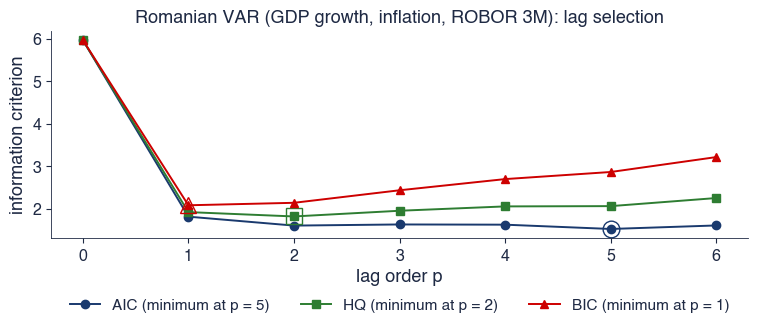

selected: {'aic': 5, 'bic': 1, 'hq': 2}
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 05, Oct, 2026
Time:                     13:28:21
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    2.31773
Nobs:                     84.0000    HQIC:                   1.95432
Log likelihood:          -408.394    FPE:                    5.53554
AIC:                      1.71003    Det(Omega_mle):         4.35386
--------------------------------------------------------------------
Results for equation g
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         1.085318         0.526352            2.062           0.039
L1.g          0.013352         0.108781            0.123           0.902
L1.pi         0.530531         0.230758            2.299

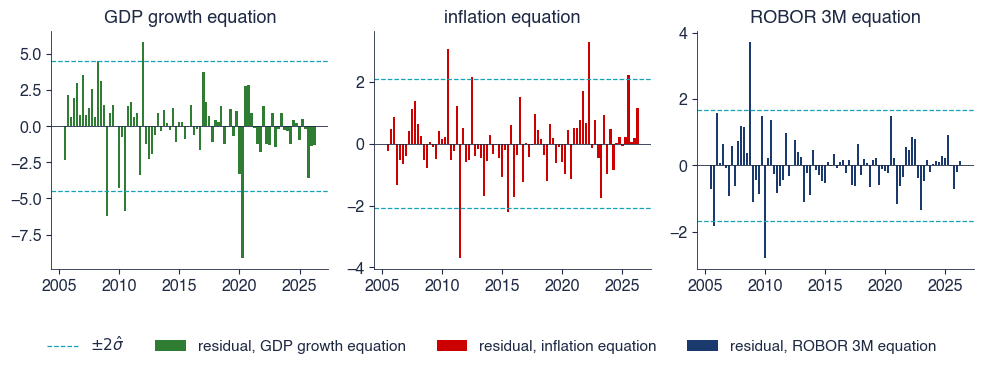

{'lb8': {'stat': 76.67994664151918, 'df': 54, 'p': 0.0228968422447569}, 'lb12': {'stat': 105.25684786637639, 'df': 90, 'p': 0.12973155919231041}, 'jb': {'stat': 190.66006578754667, 'df': 6, 'p': 1.8417597396533664e-38}}


In [8]:
def ic_romania(pmax=6):
    return ic_table(ro_var_data(), pmax)


def fig_ic(pmax=6, save_it=True):
    """AIC, BIC and HQ of the Romanian VAR for p = 0..pmax, on a common sample."""
    ic = ic_romania(pmax)
    p = np.arange(pmax + 1)
    fig, ax = plt.subplots(figsize=(8.0, 3.6))
    for c, col, mk, lab in [('aic', st.MainBlue, 'o', 'AIC'), ('hq', st.Forest, 's', 'HQ'), ('bic', st.IDAred, '^', 'BIC')]:
        vals = np.array([ic['table'][j][c] for j in p])
        ax.plot(p, vals, marker=mk, color=col, label=f"{lab} (minimum at p = {ic['best'][c]})")
        ax.plot(ic['best'][c], vals[ic['best'][c]], marker=mk, ms=12, mfc='none', mec=col, label='_nolegend_')
    ax.set_xlabel('lag order p')
    ax.set_ylabel('information criterion')
    ax.set_title('Romanian VAR (GDP growth, inflation, ROBOR 3M): lag selection')
    st.legend_outside_bottom(ax, ncol=3)
    plt.tight_layout()
    save('tsa_ch6_ic', save_it)
    return ic


def ro_estimates(p=RO_P):
    """The Romanian VAR(p): coefficients, standard errors, residual covariance and correlation, fit."""
    r = ro_fit(p)
    d = ro_var_data()
    return {'params': r.params.to_dict(), 'se': r.stderr.to_dict(), 'tvalues': r.tvalues.to_dict(),
            'sigma_u': np.asarray(r.sigma_u).tolist(), 'resid_corr': np.corrcoef(np.asarray(r.resid).T).tolist(),
            'nobs': int(r.nobs), 'first_used': str(d.index[p])[:10], 'last': str(d.index[-1])[:10],
            'n_coef': int(r.params.size), 'r2': {c: float(1 - np.var(np.asarray(r.resid)[:, j]) / np.var(d[c].values[p:]))
                                                 for j, c in enumerate(RO_VARS)}}


def fig_resid(p=RO_P, save_it=True):
    """Residuals of the Romanian VAR(2) with +-2 standard deviations; Portmanteau and normality tests."""
    r = ro_fit(p)
    d = ro_var_data()
    U = pd.DataFrame(np.asarray(r.resid), index=d.index[p:], columns=RO_VARS)
    fig, ax = plt.subplots(1, 3, figsize=(10.0, 3.2))
    out = {'largest': {}}
    for a, c in zip(ax, RO_VARS):
        s = U[c].std()
        a.bar(U.index, U[c], width=70, color=COLV[c], label=f'residual, {LABEL[c]} equation')
        a.axhline(2 * s, color=BAND, ls='--', lw=0.9, label=r'$\pm 2\hat\sigma$' if c == 'g' else '_nolegend_')
        a.axhline(-2 * s, color=BAND, ls='--', lw=0.9, label='_nolegend_')
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(f'{LABEL[c]} equation')
        years_axis(a, 5)
        j = U[c].abs().idxmax()
        out['largest'][c] = {'date': str(j)[:10], 'value': float(U[c].loc[j]), 'sd': float(s)}
    st.fig_legend_bottom(fig, ncol=4, y=-0.03)
    plt.tight_layout()
    save('tsa_ch6_resid', save_it)
    for h in (8, 12):
        w = r.test_whiteness(nlags=h, adjusted=True)
        out[f'lb{h}'] = {'stat': float(w.test_statistic), 'df': int(w.df), 'p': float(w.pvalue)}
    nt = r.test_normality()
    out['jb'] = {'stat': float(nt.test_statistic), 'df': int(nt.df), 'p': float(nt.pvalue)}
    out['skew'] = U.skew().to_dict()
    out['kurt'] = (U.kurt() + 3).to_dict()
    # without the two crisis quarters (2009Q1 and 2020Q2): dummies as exogenous variables
    dum = pd.DataFrame({'d09': (d.index == '2009-01-01').astype(float), 'd20': (d.index == '2020-04-01').astype(float)},
                       index=d.index)
    r2 = VAR(d.reset_index(drop=True), exog=dum.reset_index(drop=True)).fit(p)
    nt2 = r2.test_normality()
    out['jb_dummies'] = {'stat': float(nt2.test_statistic), 'p': float(nt2.pvalue)}
    return out


ic = fig_ic(save_it=False)
print('selected:', ic['best'])
r = ro_fit()
print(r.summary())
res = fig_resid(save_it=False)
print({k: res[k] for k in ['lb8', 'lb12', 'jb']})

## 4. Granger causality

- $F$ tests in the Romanian and market VARs; the omitted-variable Monte Carlo.

{'F': 7.264295771347798, 'p': 0.0012881217446638806, 'rss_u': 58.272859751292714, 'rss_r': 69.26795815845269, 'T': 84, 'df1': 2, 'df2': 77, 'crit5': 3.1153657966336676}
              F         p
g->pi  0.159424  0.852916
g->i   7.264296  0.001288
pi->g  2.941855  0.058726
pi->i  4.742770  0.011417
i->g   4.016254  0.021922
i->pi  0.885172  0.416800


                    F             p
sp500->dax  94.551422  2.866693e-78
sp500->bet  37.774623  2.778010e-31
dax->sp500   6.851816  1.686409e-05
dax->bet     3.230808  1.171263e-02
bet->sp500   0.981752  4.160556e-01
bet->dax     2.648366  3.162772e-02


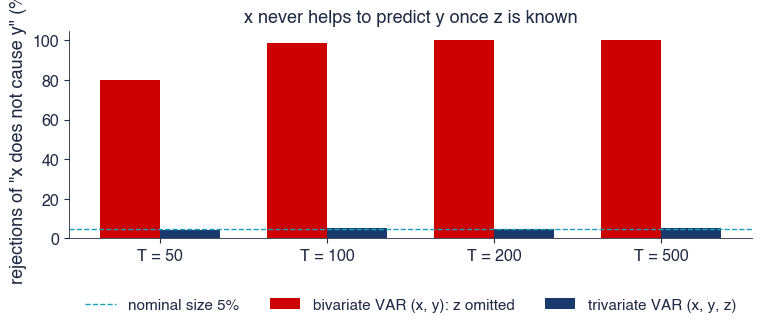

{'50': {'bivariate': 0.8, 'trivariate': 0.043},
 '100': {'bivariate': 0.989, 'trivariate': 0.053},
 '200': {'bivariate': 1.0, 'trivariate': 0.05},
 '500': {'bivariate': 1.0, 'trivariate': 0.052}}

In [9]:
def granger_romania(p=RO_P, write=False):
    d = ro_var_data()
    G = granger_table(d, p)
    r = ro_fit(p)
    inst = {c: float(r.test_inst_causality(c).pvalue) for c in RO_VARS}
    rows = [{'cause': k.split('->')[0], 'effect': k.split('->')[1], 'F': v['F'], 'p': v['p']} for k, v in G.items()]
    if write:
        pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch6_granger_romania.csv'), index=False, float_format='%.4f')
    # bivariate tests (the same pairs, two variables only)
    bi = {k: granger_F(d[[k.split('->')[0], k.split('->')[1]]], k.split('->')[0], k.split('->')[1], p)['p'] for k in G}
    sm = r.test_causality('i', ['g'], kind='wald')
    return {'tests': G, 'inst': inst, 'bivariate_p': bi, 'wald_g_i': {'stat': float(sm.test_statistic), 'p': float(sm.pvalue)}}


def granger_markets(p=MKT_P):
    r = market_returns()
    G = granger_table(r, p)
    res = fit_var(r, p)
    inst = float(res.test_inst_causality('sp500').pvalue)
    so = VAR(r.reset_index(drop=True)).select_order(10).selected_orders
    return {'tests': G, 'inst_sp500': inst, 'T': len(r), 'orders': {k: int(v) for k, v in so.items()},
            'coef_bet_sp1': float(res.params.loc['L1.sp500', 'bet']), 'coef_dax_sp1': float(res.params.loc['L1.sp500', 'dax']),
            'se_bet_sp1': float(res.stderr.loc['L1.sp500', 'bet']), 'corr': r.corr().to_dict()}


def granger_by_hand(p=RO_P):
    """The worked F test: does GDP growth Granger-cause ROBOR 3M in the Romanian VAR?"""
    return granger_F(ro_var_data(), 'g', 'i', p)


def omitted_sim(Ts=(50, 100, 200, 500), R=1000, p=2):
    """Monte Carlo of the omitted-variable pitfall: z_t = 0.5 z_{t-1} + e_t; x_t = 0.8 z_{t-1} + u_t;
    y_t = 0.8 z_{t-2} + v_t. x does not Granger-cause y given z, but in the bivariate (x, y) VAR it appears to."""
    rng = np.random.default_rng(SEED)
    out = {}
    for T in Ts:
        rej_bi = rej_tri = 0
        for _ in range(R):
            n = T + 50
            e = rng.standard_normal((n, 3))
            z = np.zeros(n)
            for t in range(1, n):
                z[t] = 0.5 * z[t - 1] + e[t, 0]
            x = np.r_[0, 0.8 * z[:-1]] + e[:, 1]
            y = np.r_[0, 0, 0.8 * z[:-2]] + e[:, 2]
            dd = pd.DataFrame({'x': x, 'y': y, 'z': z}).iloc[50:]
            rej_bi += granger_F(dd[['x', 'y']], 'x', 'y', p)['p'] < 0.05
            rej_tri += granger_F(dd, 'x', 'y', p)['p'] < 0.05
        out[T] = {'bivariate': rej_bi / R, 'trivariate': rej_tri / R}
    return out


def fig_granger_sim(save_it=True):
    sim = omitted_sim()
    Ts = list(sim)
    x = np.arange(len(Ts))
    fig, ax = plt.subplots(figsize=(8.0, 3.6))
    ax.bar(x - 0.18, [100 * sim[T]['bivariate'] for T in Ts], width=0.36, color=st.IDAred,
           label='bivariate VAR (x, y): z omitted')
    ax.bar(x + 0.18, [100 * sim[T]['trivariate'] for T in Ts], width=0.36, color=st.MainBlue,
           label='trivariate VAR (x, y, z)')
    ax.axhline(5, color=BAND, ls='--', lw=1.0, label='nominal size 5%')
    ax.set_xticks(x)
    ax.set_xticklabels([f'T = {T}' for T in Ts])
    ax.set_ylabel('rejections of "x does not cause y" (%)')
    ax.set_title('x never helps to predict y once z is known')
    st.legend_outside_bottom(ax, ncol=3)
    plt.tight_layout()
    save('tsa_ch6_granger_sim', save_it)
    return {str(k): v for k, v in sim.items()}


print(granger_by_hand())
gr = granger_romania()
print(pd.DataFrame(gr['tests']).T[['F', 'p']])
gm = granger_markets()
print(pd.DataFrame(gm['tests']).T[['F', 'p']])
fig_granger_sim(save_it=False)

## 5. Impulse responses and FEVD

- Cholesky responses with bootstrap bands; two orderings and the generalised responses; the variance decomposition.

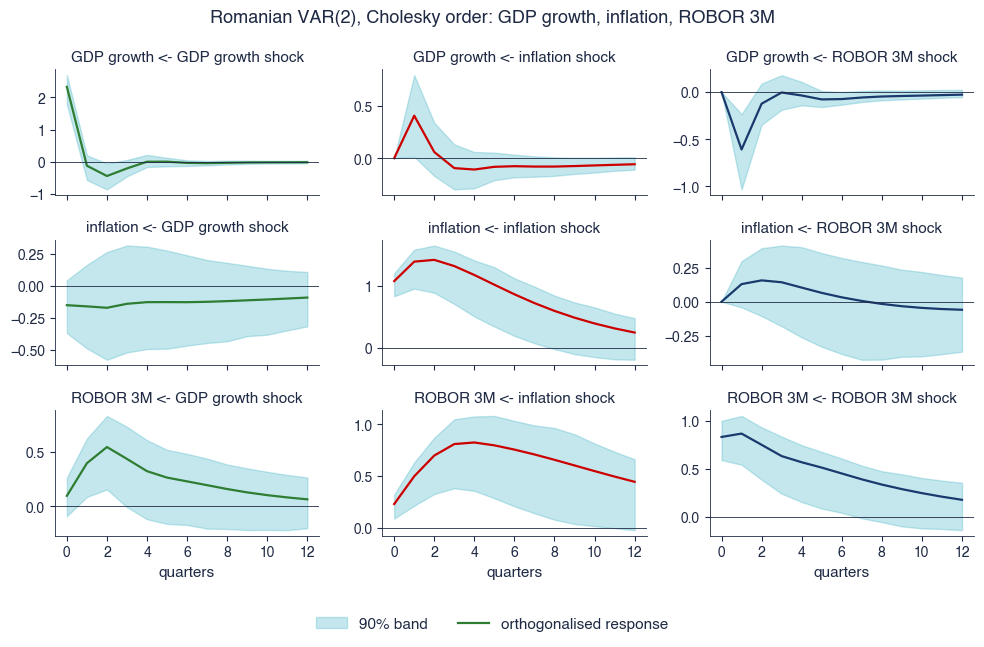

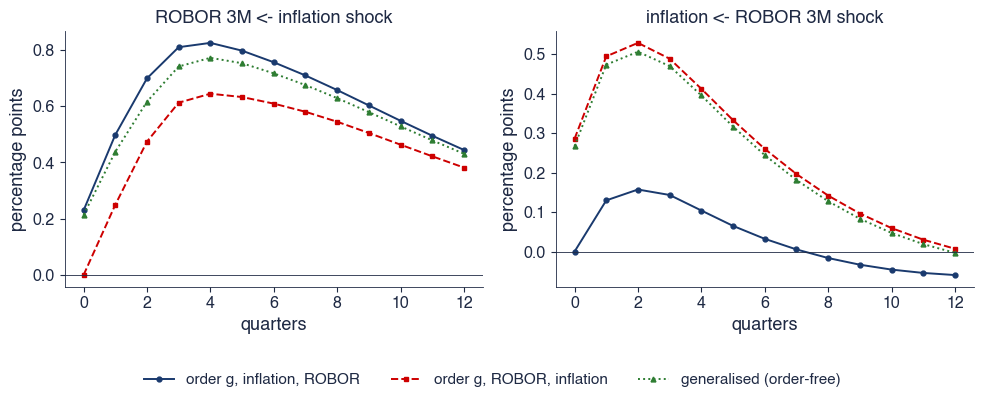

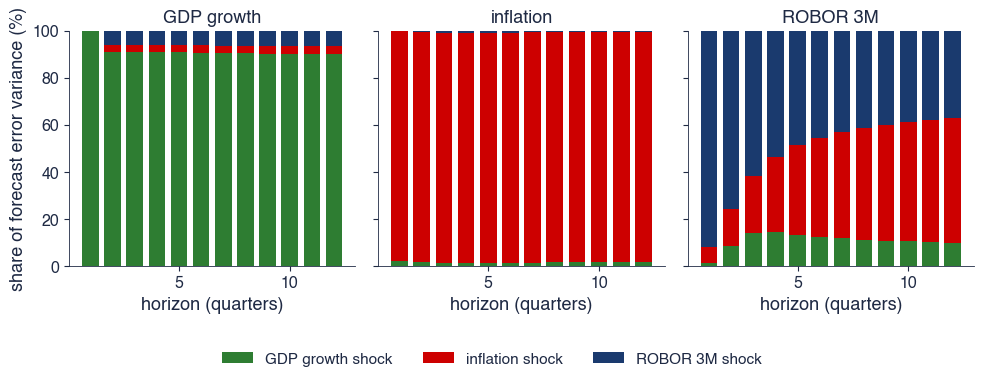

{'1': [1.2412098579994089, 6.960588547000908, 91.79820159499968], '4': [14.387205585711246, 32.036481367249664, 53.57631304703909], '8': [11.25388141652551, 47.31708296783098, 41.42903561564351], '12': [9.907883021026805, 52.79405930354998, 37.2980576754232]}


In [10]:
def fig_irf_ro(H=12, save_it=True):
    r = ro_fit()
    o, lo, hi = irf_panel(r, RO_VARS, H, 'tsa_ch6_irf_ro', 'Romanian VAR(2), Cholesky order: GDP growth, inflation, ROBOR 3M',
                          save_it=save_it)
    k = {c: j for j, c in enumerate(RO_VARS)}
    pick = lambda i, j: [float(x) for x in o[:, k[i], k[j]]]
    sig = lambda i, j: [bool(lo[h, k[i], k[j]] > 0 or hi[h, k[i], k[j]] < 0) for h in range(H + 1)]
    P = np.linalg.cholesky(np.asarray(r.sigma_u))
    return {'pi_i': pick('pi', 'i'), 'i_pi': pick('i', 'pi'), 'g_i': pick('g', 'i'), 'i_g': pick('i', 'g'),
            'pi_pi': pick('pi', 'pi'), 'i_i': pick('i', 'i'), 'g_g': pick('g', 'g'), 'pi_g': pick('pi', 'g'),
            'g_pi': pick('g', 'pi'),
            'sig_pi_i': sig('pi', 'i'), 'sig_i_pi': sig('i', 'pi'), 'sig_g_i': sig('g', 'i'),
            'P': P.tolist(), 'sd': np.sqrt(np.diag(np.asarray(r.sigma_u))).tolist()}


def fig_irf_order(H=12, save_it=True):
    """The ordering matters: responses of ROBOR to an inflation shock and of inflation to a ROBOR shock with the order
    (g, pi, i) and with the order (g, i, pi), and the generalised responses."""
    d = ro_var_data()
    rA = fit_var(d[['g', 'pi', 'i']], RO_P)
    rB = fit_var(d[['g', 'i', 'pi']], RO_P)
    oA, oB = rA.irf(H).orth_irfs, rB.irf(H).orth_irfs
    G = girf(rA, H)
    h = np.arange(H + 1)
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.6))
    ax[0].plot(h, oA[:, 2, 1], 'o-', ms=3.5, color=st.MainBlue, label='order g, inflation, ROBOR')
    ax[0].plot(h, oB[:, 1, 2], 's--', ms=3.5, color=st.IDAred, label='order g, ROBOR, inflation')
    ax[0].plot(h, G[:, 2, 1], '^:', ms=3.5, color=st.Forest, label='generalised (order-free)')
    ax[0].set_title('ROBOR 3M <- inflation shock')
    ax[1].plot(h, oA[:, 1, 2], 'o-', ms=3.5, color=st.MainBlue, label='_nolegend_')
    ax[1].plot(h, oB[:, 2, 1], 's--', ms=3.5, color=st.IDAred, label='_nolegend_')
    ax[1].plot(h, G[:, 1, 2], '^:', ms=3.5, color=st.Forest, label='_nolegend_')
    ax[1].set_title('inflation <- ROBOR 3M shock')
    for a in ax:
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_xlabel('quarters')
        a.set_ylabel('percentage points')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_irf_order', save_it)
    return {'i_pi_A': oA[:, 2, 1].tolist(), 'i_pi_B': oB[:, 1, 2].tolist(), 'i_pi_G': G[:, 2, 1].tolist(),
            'pi_i_A': oA[:, 1, 2].tolist(), 'pi_i_B': oB[:, 2, 1].tolist(), 'pi_i_G': G[:, 1, 2].tolist(),
            'corr_pi_i': float(np.corrcoef(np.asarray(rA.resid).T)[1, 2])}


def fig_fevd_ro(H=12, save_it=True):
    r = ro_fit()
    fe = r.fevd(H).decomp            # [variable, horizon, shock]
    h = np.arange(1, H + 1)
    fig, ax = plt.subplots(1, 3, figsize=(10.0, 3.4), sharey=True)
    for i, (a, c) in enumerate(zip(ax, RO_VARS)):
        bottom = np.zeros(H)
        for j, s in enumerate(RO_VARS):
            a.bar(h, 100 * fe[i, :, j], bottom=bottom, color=COLV[s], width=0.75,
                  label=f'{LABEL[s]} shock' if i == 0 else '_nolegend_')
            bottom += 100 * fe[i, :, j]
        a.set_title(f'{LABEL[c]}')
        a.set_xlabel('horizon (quarters)')
        a.set_ylim(0, 100)
    ax[0].set_ylabel('share of forecast error variance (%)')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_fevd_ro', save_it)
    return {c: {str(hh): (100 * fe[i, hh - 1, :]).tolist() for hh in (1, 4, 8, 12)} for i, c in enumerate(RO_VARS)}


fig_irf_ro(save_it=False)
fig_irf_order(save_it=False)
fe = fig_fevd_ro(save_it=False)
print(fe['i'])

## 6. Market spillovers

- Responses of DAX and BET to an S&P 500 shock; the Diebold–Yilmaz spillover index.

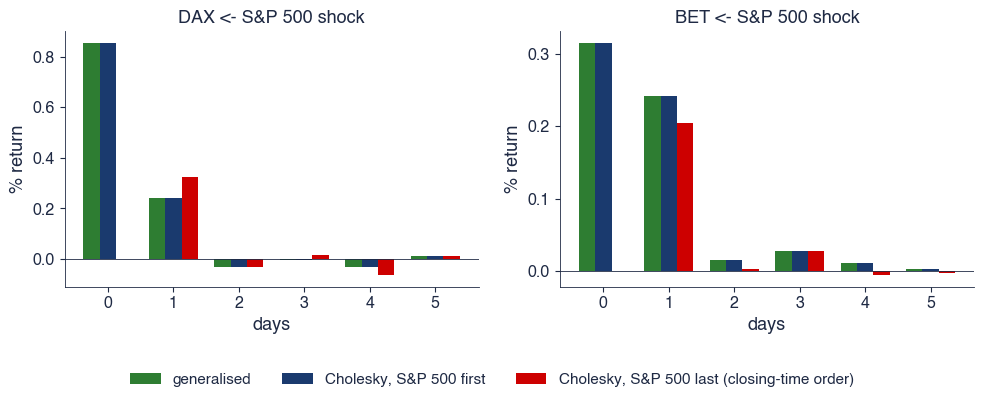

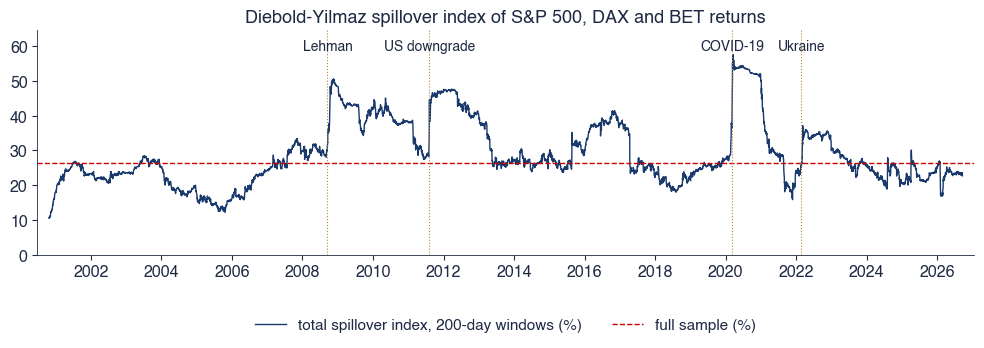

26.4 2020-03-17


In [11]:
def fig_market_irf(H=5, save_it=True):
    """Responses of DAX and BET returns to an S&P 500 shock: generalised and Cholesky with two orderings
    (S&P 500 first; the order of the closing times BET, DAX, S&P 500)."""
    r = market_returns()
    rA = fit_var(r[['sp500', 'dax', 'bet']], MKT_P)
    rB = fit_var(r[['bet', 'dax', 'sp500']], MKT_P)
    oA, oB, G = rA.irf(H).orth_irfs, rB.irf(H).orth_irfs, girf(rA, H)
    h = np.arange(H + 1)
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.6))
    for a, (iA, iB, nm) in zip(ax, [(1, 1, 'dax'), (2, 0, 'bet')]):
        a.bar(h - 0.25, G[:, iA, 0], width=0.25, color=st.Forest, label='generalised')
        a.bar(h, oA[:, iA, 0], width=0.25, color=st.MainBlue, label='Cholesky, S&P 500 first')
        a.bar(h + 0.25, oB[:, iB, 2], width=0.25, color=st.IDAred, label='Cholesky, S&P 500 last (closing-time order)')
        a.axhline(0, color=st.DarkText, lw=0.6)
        a.set_title(f'{LABEL[nm]} <- S&P 500 shock')
        a.set_xlabel('days')
        a.set_ylabel('% return')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_market_irf', save_it)
    sd = np.sqrt(np.diag(np.asarray(rA.sigma_u)))
    return {'G_dax': G[:, 1, 0].tolist(), 'G_bet': G[:, 2, 0].tolist(), 'A_dax': oA[:, 1, 0].tolist(),
            'A_bet': oA[:, 2, 0].tolist(), 'B_dax': oB[:, 1, 2].tolist(), 'B_bet': oB[:, 0, 2].tolist(),
            'sd': dict(zip(['sp500', 'dax', 'bet'], sd.tolist())),
            'corr_u': np.corrcoef(np.asarray(rA.resid).T).tolist()}


def spillover_table(r=None, write=False):
    r = market_returns() if r is None else r
    th = gfevd(fit_var(r, MKT_P), DY_H)
    K = th.shape[0]
    tab = pd.DataFrame(100 * th, index=[LABEL[c] for c in r.columns], columns=[LABEL[c] for c in r.columns])
    tab['from others'] = tab.sum(axis=1) - np.diag(tab.values)
    to = tab.iloc[:, :K].sum(axis=0) - np.diag(tab.values[:, :K])
    tab.loc['to others'] = list(to.values) + [spill_index(th)]
    if write:
        tab.to_csv(os.path.join(HERE, 'ch6_spillover_table.csv'), float_format='%.1f')
    return th, tab


def rolling_spillover(r=None, W=DY_W, step=1):
    r = market_returns() if r is None else r
    vals = {}
    for e in range(W, len(r) + 1, step):
        vals[r.index[e - 1]] = spill_index(gfevd(fit_var(r.iloc[e - W:e], MKT_P), DY_H))
    return pd.Series(vals)


def fig_spillover(save_it=True):
    r = market_returns()
    th, tab = spillover_table(r, write=save_it)
    s = rolling_spillover(r)
    fig, ax = plt.subplots(figsize=(10.0, 3.8))
    ax.plot(s.index, s.values, color=st.MainBlue, lw=1.0, label='total spillover index, 200-day windows (%)')
    ax.axhline(spill_index(th), color=st.IDAred, ls='--', lw=1.0, label='full sample (%)')
    for dte, lab in [('2008-09-15', 'Lehman'), ('2011-08-05', 'US downgrade'), ('2020-03-11', 'COVID-19'),
                     ('2022-02-24', 'Ukraine')]:
        ax.axvline(pd.Timestamp(dte), color=st.Amber, lw=0.8, ls=':')
        ax.text(pd.Timestamp(dte), s.max() * 1.02, lab, color=st.DarkText, fontsize=10, ha='center')
    ax.set_ylim(0, s.max() * 1.12)
    ax.set_xlim(s.index[0] - pd.Timedelta(days=120), s.index[-1] + pd.Timedelta(days=120))
    years_axis(ax, 2)
    ax.set_title('Diebold-Yilmaz spillover index of S&P 500, DAX and BET returns')
    st.legend_outside_bottom(ax, ncol=2)
    plt.tight_layout()
    save('tsa_ch6_spillover', save_it)
    yr = s.groupby(s.index.year).mean()
    return {'table': {i: tab.loc[i].to_dict() for i in tab.index}, 'total': float(spill_index(th)),
            'roll_mean': float(s.mean()), 'roll_max': float(s.max()), 'roll_max_d': str(s.idxmax())[:10],
            'roll_min': float(s.min()), 'roll_min_d': str(s.idxmin())[:10], 'roll_last': float(s.iloc[-1]),
            'year_max': int(yr.idxmax()), 'year_min': int(yr.idxmin()), 'n_windows': int(len(s)),
            'v2007': float(s.loc['2007'].mean()), 'v2008q4': float(s.loc['2008-10':'2008-12'].mean()),
            'v2020': float(s.loc['2020-03':'2020-06'].mean())}


fig_market_irf(save_it=False)
sp = fig_spillover(save_it=False)
print(round(sp['total'], 1), sp['roll_max_d'])

## 7. Forecasting

- VAR forecasts with intervals; out-of-sample comparison with AR models and the random walk.

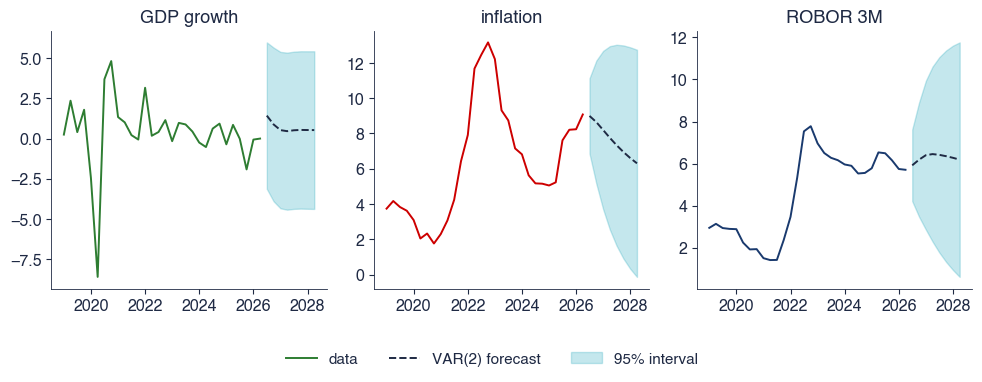

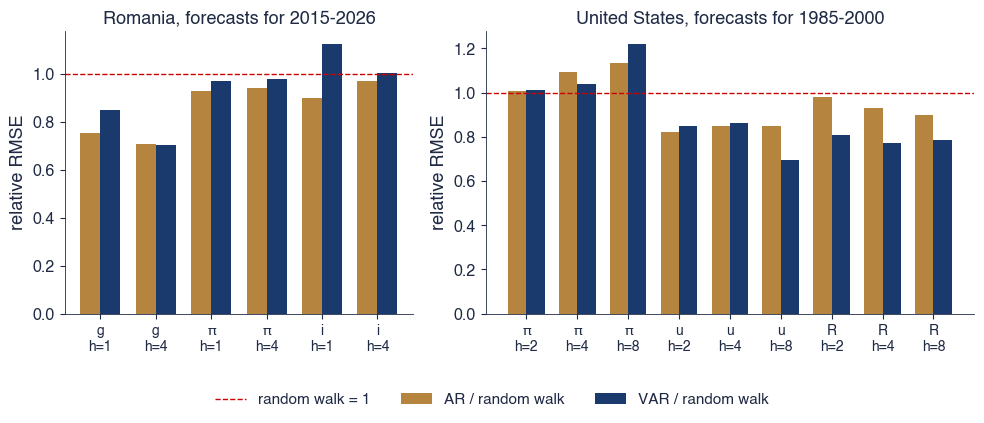

         VAR        AR        RW
g   2.265800  2.010513  2.665023
pi  1.137296  1.087898  1.171643
i   0.657091  0.526780  0.585163


In [12]:
def fig_forecast_ro(H=8, save_it=True):
    d = ro_var_data()
    r = fit_var(d, RO_P)
    pt, lo, hi = r.forecast_interval(d.values[-RO_P:], H, alpha=0.05)
    fidx = pd.date_range(d.index[-1] + pd.offsets.QuarterBegin(startingMonth=1), periods=H, freq='QS')
    fig, ax = plt.subplots(1, 3, figsize=(10.0, 3.4))
    for j, (a, c) in enumerate(zip(ax, RO_VARS)):
        hist = d[c].loc['2019-01-01':]
        a.plot(hist.index, hist, color=COLV[c], label='data' if j == 0 else '_nolegend_')
        a.plot(fidx, pt[:, j], color=st.DarkText, ls='--', label='VAR(2) forecast' if j == 0 else '_nolegend_')
        a.fill_between(fidx, lo[:, j], hi[:, j], color=BAND, alpha=0.25, label='95% interval' if j == 0 else '_nolegend_')
        a.set_title(LABEL[c])
        years_axis(a, 2)
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_forecast_ro', save_it)
    mu = np.linalg.solve(np.eye(3) - sum(r.coefs), r.intercept)
    return {'first_f': qlabel(fidx[0]), 'last_f': qlabel(fidx[-1]), 'last_obs': qlabel(d.index[-1]),
            'last': d.iloc[-1].to_dict(), 'pt': pt.tolist(), 'lo': lo.tolist(), 'hi': hi.tolist(),
            'mu': dict(zip(RO_VARS, mu.tolist()))}


def oos(d, p, start, hs, pmax_ar=4):
    """Pseudo out-of-sample forecasts with an expanding window: VAR(p), AR(p_AIC) for each variable and the random walk
    (no change). Returns RMSE by model, variable and horizon, and the forecast errors."""
    cols = list(d.columns)
    i0 = d.index.get_loc(pd.Timestamp(start))
    err = {m: {c: {h: [] for h in hs} for c in cols} for m in ('VAR', 'AR', 'RW')}
    for t in range(i0, len(d) + 1):          # origin: last observation at t-1
        train = d.iloc[:t]
        r = fit_var(train, p)
        fc = r.forecast(train.values[-p:], max(hs))
        for h in hs:
            if t - 1 + h >= len(d):
                continue
            actual = d.iloc[t - 1 + h]
            for j, c in enumerate(cols):
                y = train[c].values
                err['VAR'][c][h].append(actual[c] - fc[h - 1, j])
                err['AR'][c][h].append(actual[c] - ar_forecast(y, h, pmax_ar)[0])
                err['RW'][c][h].append(actual[c] - y[-1])
    rmse = {m: {c: {h: float(np.sqrt(np.mean(np.square(err[m][c][h])))) for h in hs} for c in cols} for m in err}
    return rmse, err


def fig_oos(save_it=True):
    """Relative RMSE (model / random walk) of VAR and AR forecasts: Romania (2015Q1-2026Q2, h = 1, 4) and the United
    States (Stock-Watson evaluation period 1985Q1-2000Q4, h = 2, 4, 8)."""
    dro = ro_var_data()
    rro, ero = oos(dro, RO_P, '2015-01-01', (1, 4))
    dus = us_sw(SW_START, SW_END)
    rus, eus = oos(dus, SW_P, '1985-01-01', (2, 4, 8))
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.8), gridspec_kw={'width_ratios': [1, 1.4]})
    for a, rm, cols, hs, ttl in [(ax[0], rro, RO_VARS, (1, 4), 'Romania, forecasts for 2015-2026'),
                                 (ax[1], rus, SW_VARS, (2, 4, 8), 'United States, forecasts for 1985-2000')]:
        groups = [(c, h) for c in cols for h in hs]
        x = np.arange(len(groups))
        a.bar(x - 0.18, [rm['AR'][c][h] / rm['RW'][c][h] for c, h in groups], width=0.36, color=st.Amber, label='AR / random walk')
        a.bar(x + 0.18, [rm['VAR'][c][h] / rm['RW'][c][h] for c, h in groups], width=0.36, color=st.MainBlue,
              label='VAR / random walk')
        a.axhline(1, color=st.IDAred, ls='--', lw=1.0, label='random walk = 1')
        a.set_xticks(x)
        a.set_xticklabels([f'{c}\nh={h}'.replace('pi', 'π') for c, h in groups], fontsize=10)
        a.set_title(ttl)
        a.set_ylabel('relative RMSE')
    handles, labels = ax[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, handles, labels, ncol=3, y=-0.02)
    plt.tight_layout()
    save('tsa_ch6_oos', save_it)
    dm = {c: dm_test(ero['VAR'][c][1], ero['AR'][c][1], 1) for c in RO_VARS}
    dmu = {c: dm_test(eus['VAR'][c][4], eus['AR'][c][4], 4) for c in SW_VARS}
    return {'ro': rro, 'us': rus, 'n_ro': len(ero['VAR']['g'][1]), 'n_us4': len(eus['VAR']['pi'][4]),
            'dm_ro': dm, 'dm_us4': dmu}


fig_forecast_ro(save_it=False)
ev = fig_oos(save_it=False)
print(pd.DataFrame({m: {c: ev['ro'][m][c][1] for c in RO_VARS} for m in ['VAR', 'AR', 'RW']}))

## 8. Case study: Stock and Watson (2001)

- Inflation, unemployment, federal funds rate; VAR(4), 1960Q1–2000Q4.

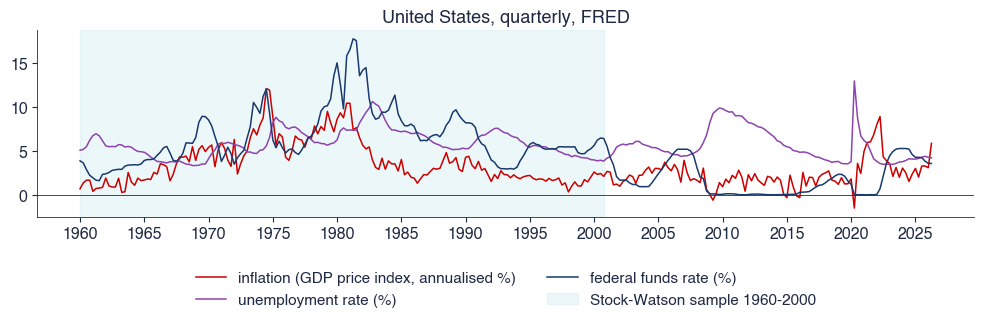

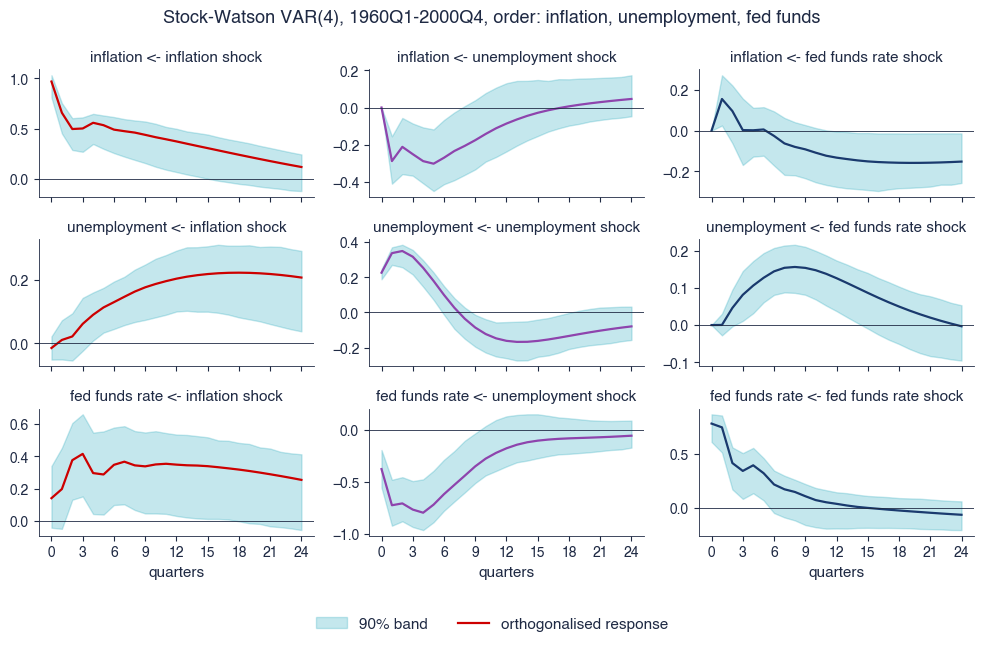

{'pi->u': 0.21009790546691196, 'pi->R': 0.00012597686230033763, 'u->pi': 0.035800817887519, 'u->R': 1.3477275014139278e-05, 'R->pi': 0.4016677154972799, 'R->u': 0.003260526492364505}


In [13]:
def fig_us_data(save_it=True):
    d = us_sw(SW_START)
    fig, ax = plt.subplots(figsize=(10.0, 3.6))
    for c, col in [('pi', st.IDAred), ('u', st.Purple), ('R', st.MainBlue)]:
        ax.plot(d.index, d[c], color=col, lw=1.1, label={'pi': 'inflation (GDP price index, annualised %)',
                                                           'u': 'unemployment rate (%)', 'R': 'federal funds rate (%)'}[c])
    ax.axvspan(pd.Timestamp(SW_START), pd.Timestamp(SW_END), color=st.Teal, alpha=0.08, label='Stock-Watson sample 1960-2000')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    years_axis(ax, 5)
    ax.set_title('United States, quarterly, FRED')
    st.legend_outside_bottom(ax, ncol=2)
    plt.tight_layout()
    save('tsa_ch6_us_data', save_it)
    return {'first': qlabel(d.index[0]), 'last': qlabel(d.index[-1]), 'T_sw': len(us_sw(SW_START, SW_END)),
            'T_all': len(d)}


def fig_sw_irf(H=24, save_it=True):
    d = us_sw(SW_START, SW_END)
    r = fit_var(d, SW_P)
    o, lo, hi = irf_panel(r, SW_VARS, H, 'tsa_ch6_sw_irf', 'Stock-Watson VAR(4), 1960Q1-2000Q4, order: inflation, unemployment, fed funds',
                          save_it=save_it)
    G = granger_table(d, SW_P)
    fe = r.fevd(12).decomp
    full = us_sw(SW_START)
    rf = fit_var(full, SW_P)
    of = rf.irf(H).orth_irfs
    Gf = granger_table(full, SW_P)
    k = {c: j for j, c in enumerate(SW_VARS)}
    return {'granger': {kk: v['p'] for kk, v in G.items()}, 'granger_full': {kk: v['p'] for kk, v in Gf.items()},
            'fevd': {c: {str(hh): (100 * fe[k[c], hh - 1, :]).tolist() for hh in (1, 4, 8, 12)} for c in SW_VARS},
            'u_R': o[:, k['u'], k['R']].tolist(), 'pi_R': o[:, k['pi'], k['R']].tolist(), 'R_R': o[:, k['R'], k['R']].tolist(),
            'R_pi': o[:, k['R'], k['pi']].tolist(), 'R_u': o[:, k['R'], k['u']].tolist(),
            'u_R_full': of[:, k['u'], k['R']].tolist(), 'pi_R_full': of[:, k['pi'], k['R']].tolist(),
            'sig_pi_R': [bool(lo[h, 0, 2] > 0 or hi[h, 0, 2] < 0) for h in range(H + 1)],
            'sig_u_R': [bool(lo[h, 1, 2] > 0 or hi[h, 1, 2] < 0) for h in range(H + 1)],
            'max_mod': float(np.abs(np.linalg.eigvals(companion(r))).max()),
            'max_mod_full': float(np.abs(np.linalg.eigvals(companion(rf))).max()), 'T': int(r.nobs),
            'T_full': int(rf.nobs), 'last_full': qlabel(full.index[-1]), 'n_coef': int(r.params.size)}


fig_us_data(save_it=False)
sw = fig_sw_irf(save_it=False)
print(sw['granger'])

## Exercises

1. Add the unemployment rate `u` to the Romanian VAR (`ro_var_data(['g', 'u', 'pi', 'i'])`): does it Granger-cause anything?
2. Recompute the Romanian responses with the order (i, pi, g): which conclusions survive?
3. Compute the spillover index with the Nasdaq 100 (`'ndx'`) instead of the S&P 500.